# Exploring Word Representations: From Traditional Embeddings to Transformers
**24ADI306 Deep Learning – Self Learning Assignment (CO3)**

Name: Swathi V  Roll No:24BAD122
**Pipeline**
1. Dataset and preprocessing (20 Newsgroups, 4 topics)
2. Traditional representations: One-Hot, BoW, TF-IDF, N-grams, Co-occurrence + SVD (LSA)
3. Word2Vec (Skip-gram and CBOW) + cosine-similarity top-5 neighbours + analogies
4. FastText (out-of-vocabulary handling) and GloVe (pretrained)
5. Neural embeddings with the TensorFlow/Keras `Embedding` layer
6. Contextual embeddings with BERT (and SBERT)
7. Visualization: PCA, t-SNE, UMAP, TensorFlow Embedding Projector
8. Comparison table

Run on Google Colab (Runtime -> Run all). Internet is needed for the dataset and pretrained models.

In [ ]:
!pip install -q gensim umap-learn sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 14.5 MB/s eta 0:00:00


In [ ]:
import re, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.random.seed(42)

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import (CountVectorizer, TfidfVectorizer,
                                             ENGLISH_STOP_WORDS)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from gensim.models import Word2Vec, FastText
print("Imports OK")

Imports OK


## 1. Dataset and preprocessing

In [ ]:
cats = ["sci.space", "rec.sport.baseball", "comp.graphics", "talk.politics.mideast"]
data = fetch_20newsgroups(subset="all", categories=cats,
                          remove=("headers", "footers", "quotes"))
docs, labels = data.data, data.target
print(len(docs), "documents;", "classes:", data.target_names)

def tokenize(text):
    toks = re.findall(r"[a-z]+", text.lower())
    return [t for t in toks if t not in ENGLISH_STOP_WORDS and len(t) > 2]

tokenized = [tokenize(d) for d in docs]
keep = [i for i, t in enumerate(tokenized) if len(t) >= 5]     # drop near-empty docs
tokenized = [tokenized[i] for i in keep]
docs      = [docs[i] for i in keep]
labels    = np.array(labels)[keep]
clean     = [" ".join(t) for t in tokenized]
print("After cleaning:", len(clean), "docs; avg tokens/doc =",
      round(np.mean([len(t) for t in tokenized]), 1))
print(clean[0][:200])

3894 documents; classes: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.mideast']
After cleaning: 3651 docs; avg tokens/doc = 110.5
copyright status data restrictions regarding uses kaveh


## 2. Traditional text representations
### 2.1 One-Hot, Bag of Words, N-grams (toy example to see the mechanics)

In [ ]:
toy = ["the cat sat on the mat", "the dog sat on the log", "cats and dogs are pets"]

# One-hot for words in the vocabulary
vocab = sorted({w for s in toy for w in s.split()})
one_hot = {w: np.eye(len(vocab))[i] for i, w in enumerate(vocab)}
print("One-hot 'cat':", one_hot["cat"].astype(int))
print("cosine(cat, dog) =", cosine_similarity([one_hot['cat']], [one_hot['dog']])[0, 0],
      " -> every pair of distinct words is orthogonal: no notion of similarity")

bow = CountVectorizer()
print(pd.DataFrame(bow.fit_transform(toy).toarray(), columns=bow.get_feature_names_out()))

bigram = CountVectorizer(ngram_range=(1, 2))
bigram.fit(toy)
print("Uni+bi-gram features:", len(bigram.get_feature_names_out()), "vs unigrams:", len(bow.get_feature_names_out()))

One-hot 'cat': [0 0 1 0 0 0 0 0 0 0 0 0]
cosine(cat, dog) = 0.0  -> every pair of distinct words is orthogonal: no notion of similarity
   and  are  cat  cats  dog  dogs  log  mat  on  pets  sat  the
0    0    0    1     0    0     0    0    1   1     0    1    2
1    0    0    0     0    1     0    1    0   1     0    1    2
2    1    1    0     1    0     1    0    0   0     1    0    0
Uni+bi-gram features: 24 vs unigrams: 12


### 2.2 TF-IDF on the real dataset (document vectors and word vectors)

In [ ]:
tfidf = TfidfVectorizer(min_df=5, max_df=0.5, max_features=8000)
X = tfidf.fit_transform(clean)                 # (docs x terms), sparse
terms = tfidf.get_feature_names_out()
term_index = {t: i for i, t in enumerate(terms)}
print("TF-IDF matrix:", X.shape, "| sparsity: %.2f%%" % (100 * (1 - X.nnz / np.prod(X.shape))))

# A word's TF-IDF vector = its column (which documents it appears in, weighted)
Xt = X.T.tocsr()                               # (terms x docs)

def top_k_tfidf(word, k=5):
    if word not in term_index: return None
    sims = cosine_similarity(Xt[term_index[word]], Xt).ravel()
    idx = sims.argsort()[::-1][1:k+1]
    return [(terms[i], round(float(sims[i]), 3)) for i in idx]

for q in ["nasa", "baseball", "israel", "graphics"]:
    print(q, "->", top_k_tfidf(q))

TF-IDF matrix: (3651, 8000) | sparsity: 99.25%
nasa -> [('gov', 0.452), ('ames', 0.375), ('space', 0.361), ('jsc', 0.338), ('kjenks', 0.329)]
baseball -> [('football', 0.236), ('players', 0.217), ('stepping', 0.207), ('game', 0.203), ('steph', 0.201)]
israel -> [('israeli', 0.39), ('arab', 0.357), ('lebanon', 0.356), ('lebanese', 0.313), ('arabs', 0.311)]
graphics -> [('comp', 0.419), ('computer', 0.304), ('library', 0.203), ('programming', 0.203), ('ecr', 0.191)]


### 2.3 Co-occurrence matrix + SVD (LSA): dense vectors from counts

In [ ]:
from scipy.sparse import csr_matrix
# Word-word co-occurrence within a +-4 window over the 5000 most frequent words
from collections import Counter
freq = Counter(w for t in tokenized for w in t)
V = [w for w, _ in freq.most_common(5000)]
widx = {w: i for i, w in enumerate(V)}
rows, cols, vals = [], [], []
WIN = 4
for t in tokenized:
    ids = [widx[w] for w in t if w in widx]
    for i, a in enumerate(ids):
        for b in ids[max(0, i - WIN): i]:
            rows += [a, b]; cols += [b, a]; vals += [1, 1]
co = csr_matrix((vals, (rows, cols)), shape=(len(V), len(V)), dtype=np.float32)

# Positive PMI weighting then truncated SVD -> 100-d dense vectors
total = co.sum(); rs = np.asarray(co.sum(1)).ravel(); cs = np.asarray(co.sum(0)).ravel()
co = co.tocoo()
pmi = np.log((co.data * total) / (rs[co.row] * cs[co.col] + 1e-9) + 1e-9)
ppmi = csr_matrix((np.maximum(pmi, 0), (co.row, co.col)), shape=co.shape)
svd = TruncatedSVD(n_components=min(100, len(V) - 1), random_state=42)
lsa_vecs = svd.fit_transform(ppmi)

def top_k_generic(vecs, index, words, word, k=5):
    if word not in index: return None
    sims = cosine_similarity(vecs[index[word]].reshape(1, -1), vecs).ravel()
    idx = sims.argsort()[::-1][1:k+1]
    return [(words[i], round(float(sims[i]), 3)) for i in idx]

for q in ["nasa", "baseball", "israel", "graphics"]:
    print(q, "->", top_k_generic(lsa_vecs, widx, V, q))

nasa -> [('space', 0.834), ('jpl', 0.826), ('gov', 0.804), ('ames', 0.797), ('jsc', 0.782)]
baseball -> [('games', 0.853), ('teams', 0.82), ('team', 0.814), ('play', 0.812), ('season', 0.808)]
israel -> [('israeli', 0.922), ('arab', 0.874), ('arabs', 0.871), ('palestinians', 0.871), ('peace', 0.821)]
graphics -> [('code', 0.809), ('unix', 0.804), ('available', 0.801), ('package', 0.787), ('pub', 0.783)]


## 3. Word2Vec: Skip-gram and CBOW
`sg=1` -> Skip-gram (predict context from centre word; better for rare words).
`sg=0` -> CBOW (predict centre word from averaged context; faster).

In [ ]:
w2v_sg = Word2Vec(tokenized, vector_size=100, window=5, min_count=5, sg=1,
                  negative=10, epochs=15, workers=4, seed=42)
w2v_cbow = Word2Vec(tokenized, vector_size=100, window=5, min_count=5, sg=0,
                    negative=10, epochs=15, workers=4, seed=42)
print("Vocabulary size:", len(w2v_sg.wv))

queries = [q for q in ["nasa", "baseball", "israel", "graphics", "orbit", "pitcher"] if q in w2v_sg.wv]
rows = []
for q in queries:
    rows.append({"query": q,
                 "Skip-gram top-5": ", ".join(w for w, _ in w2v_sg.wv.most_similar(q, topn=5)),
                 "CBOW top-5":      ", ".join(w for w, _ in w2v_cbow.wv.most_similar(q, topn=5))})
pd.set_option("display.max_colwidth", 200)
pd.DataFrame(rows)

Vocabulary size: 10800


,query,Skip-gram top-5,CBOW top-5
0,nasa,"larc, egalon, ames, miya, baalke","jpl, jsc, ames, gov, astronaut"
1,baseball,"football, hockey, nfl, boring, games","sport, football, players, teams, stat"
2,israel,"arabs, palestinians, gemayel, israeli, arab","israeli, lebanon, arabs, syria, palestinians"
3,graphics,"mirrored, interpreter, exponent, pmview, programmer","sys, programmer, animation, procedural, multimedia"
4,orbit,"hiten, capsule, insertion, polar, maneuvering","fuel, pluto, mercury, hst, reentry"
5,pitcher,"pitches, mound, farr, bullpen, clemens","pitchers, catcher, hitters, alomar, rbi"


In [ ]:
# Cosine similarity done by hand (to show what most_similar does) + relationships
def cos(a, b): return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
wv = w2v_sg.wv
pairs = [("nasa", "space"), ("baseball", "pitcher"), ("nasa", "baseball")]
for a, b in pairs:
    if a in wv and b in wv: print(f"cos({a}, {b}) = {cos(wv[a], wv[b]):.3f}")

# Analogy-style query: vec(a) - vec(b) + vec(c)
try:
    print(wv.most_similar(positive=["israel", "baseball"], negative=["nasa"], topn=5))
except KeyError as e:
    print("word missing:", e)

cos(nasa, space) = 0.550
cos(baseball, pitcher) = 0.474
cos(nasa, baseball) = 0.200
[('discourage', 0.5166724920272827), ('prejudice', 0.5099685192108154), ('assertion', 0.49483606219291687), ('sex', 0.4930447041988373), ('immoral', 0.49060511589050293)]


## 4. FastText and GloVe
### 4.1 FastText: out-of-vocabulary handling
FastText represents a word as the sum of its character n-gram vectors, so it can build a vector for a word it has never seen (typos, rare inflections).

In [ ]:
ft = FastText(tokenized, vector_size=100, window=5, min_count=5, sg=1,
              min_n=3, max_n=6, epochs=15, workers=4, seed=42)

oov_words = ["spacecrafts", "basebal", "grafics", "nasaaa"]     # typos / rare forms
for w in oov_words:
    in_w2v = w in w2v_sg.wv
    in_ft_vocab = w in ft.wv.key_to_index
    print(f"\n'{w}': in Word2Vec vocab? {in_w2v} | in FastText vocab? {in_ft_vocab}")
    try:
        w2v_sg.wv[w]
    except KeyError:
        print("   Word2Vec -> KeyError (no vector)")
    print("   FastText  ->", [x for x, _ in ft.wv.most_similar(w, topn=5)])


'spacecrafts': in Word2Vec vocab? False | in FastText vocab? False
   Word2Vec -> KeyError (no vector)
   FastText  -> ['spacecraft', 'craft', 'spacelab', 'spacehab', 'spacewalk']

'basebal': in Word2Vec vocab? False | in FastText vocab? False
   Word2Vec -> KeyError (no vector)
   FastText  -> ['baseball', 'basketball', 'football', 'ballpark', 'ballgame']

'grafics': in Word2Vec vocab? False | in FastText vocab? False
   Word2Vec -> KeyError (no vector)
   FastText  -> ['ics', 'grafsys', 'grafitti', 'uvacs', 'grad']

'nasaaa': in Word2Vec vocab? False | in FastText vocab? False
   Word2Vec -> KeyError (no vector)
   FastText  -> ['nasa', 'nas', 'nasp', 'nasda', 'dfrf']


### 4.2 GloVe (pretrained, Wikipedia + Gigaword)

In [ ]:
import gensim.downloader as api
try:
    glove = api.load("glove-wiki-gigaword-100")      # ~130 MB, cached after first download
    for q in ["space", "baseball", "israel", "graphics"]:
        print(q, "->", [w for w, _ in glove.most_similar(q, topn=5)])
    print("king - man + woman ->", glove.most_similar(positive=["king", "woman"], negative=["man"], topn=3))
except Exception as e:
    glove = None
    print("GloVe download failed (check internet):", e)

[==================================================] 100.0% 128.1/128.1MB downloaded
space -> ['nasa', 'spaces', 'shuttle', 'earth', 'spacecraft']
baseball -> ['basketball', 'leagues', 'football', 'league', 'hockey']
israel -> ['israeli', 'palestinians', 'palestinian', 'lebanon', 'syria']
graphics -> ['layouts', 'graphic', '3d', 'multimedia', 'graphical']
king - man + woman -> [('queen', 0.7698540687561035), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]


## 5. Neural embeddings with the TensorFlow / Keras `Embedding` layer
The embedding matrix is a trainable lookup table learned with a downstream task
(here: predict the newsgroup). Words that help the same class end up close together.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

MAX_TOKENS, SEQ_LEN, EMB_DIM = 10000, 200, 64
vectorize = layers.TextVectorization(max_tokens=MAX_TOKENS, output_sequence_length=SEQ_LEN)
vectorize.adapt(tf.constant(clean))
seqs = vectorize(tf.constant(clean))
y = tf.constant(labels)

kmodel = models.Sequential([
    layers.Embedding(MAX_TOKENS, EMB_DIM, mask_zero=True, name="embedding"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(len(cats), activation="softmax"),
])
kmodel.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
hist = kmodel.fit(seqs, y, epochs=12, batch_size=32, validation_split=0.2, verbose=2)

Epoch 1/12
92/92 - 4s - 39ms/step - accuracy: 0.6682 - loss: 1.2996 - val_accuracy: 0.8755 - val_loss: 1.0981
Epoch 2/12
92/92 - 1s - 15ms/step - accuracy: 0.9151 - loss: 0.7153 - val_accuracy: 0.9371 - val_loss: 0.4412
Epoch 3/12
92/92 - 1s - 16ms/step - accuracy: 0.9599 - loss: 0.2647 - val_accuracy: 0.9453 - val_loss: 0.2540
Epoch 4/12
92/92 - 2s - 17ms/step - accuracy: 0.9839 - loss: 0.1167 - val_accuracy: 0.9466 - val_loss: 0.2085
Epoch 5/12
92/92 - 1s - 16ms/step - accuracy: 0.9921 - loss: 0.0676 - val_accuracy: 0.9466 - val_loss: 0.1957
Epoch 6/12
92/92 - 2s - 23ms/step - accuracy: 0.9959 - loss: 0.0401 - val_accuracy: 0.9453 - val_loss: 0.1912
Epoch 7/12
92/92 - 3s - 32ms/step - accuracy: 0.9976 - loss: 0.0292 - val_accuracy: 0.9480 - val_loss: 0.1925
Epoch 8/12
92/92 - 2s - 19ms/step - accuracy: 0.9997 - loss: 0.0173 - val_accuracy: 0.9425 - val_loss: 0.1948
Epoch 9/12
92/92 - 2s - 19ms/step - accuracy: 0.9990 - loss: 0.0171 - val_accuracy: 0.9439 - val_loss: 0.2011
Epoch 10/1

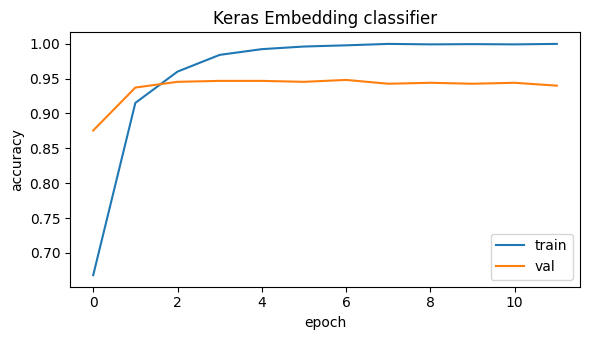

nasa -> [(np.str_('space'), 0.975), (np.str_('mission'), 0.961), (np.str_('technology'), 0.96), (np.str_('earth'), 0.959), (np.str_('launched'), 0.954)]
baseball -> [(np.str_('games'), 0.966), (np.str_('cubs'), 0.964), (np.str_('hit'), 0.961), (np.str_('bat'), 0.961), (np.str_('sox'), 0.96)]
israel -> [(np.str_('jews'), 0.991), (np.str_('armenian'), 0.99), (np.str_('israeli'), 0.99), (np.str_('armenians'), 0.989), (np.str_('turks'), 0.989)]
graphics -> [(np.str_('polygon'), 0.982), (np.str_('comp'), 0.981), (np.str_('color'), 0.98), (np.str_('animation'), 0.98), (np.str_('tiff'), 0.978)]


In [ ]:
plt.figure(figsize=(6, 3.5))
plt.plot(hist.history["accuracy"], label="train"); plt.plot(hist.history["val_accuracy"], label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title("Keras Embedding classifier"); plt.legend(); plt.tight_layout(); plt.show()

keras_vocab = vectorize.get_vocabulary()
keras_vecs = kmodel.get_layer("embedding").get_weights()[0]
kidx = {w: i for i, w in enumerate(keras_vocab)}
for q in ["nasa", "baseball", "israel", "graphics"]:
    print(q, "->", top_k_generic(keras_vecs, kidx, keras_vocab, q))

## 6. Contextual embeddings: BERT
Unlike Word2Vec/GloVe (one vector per word), BERT gives a different vector for each *occurrence* depending on the sentence.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel
tok = AutoTokenizer.from_pretrained("bert-base-uncased")
bert = AutoModel.from_pretrained("bert-base-uncased").eval()

def word_vec(sentence, word):
    enc = tok(sentence, return_tensors="pt")
    with torch.no_grad():
        hs = bert(**enc).last_hidden_state[0]
    pieces = tok.convert_ids_to_tokens(enc["input_ids"][0])
    idx = [i for i, p in enumerate(pieces) if p == word]
    return hs[idx[0]].numpy()

sents = {
  "river":   "He sat on the bank of the river and watched the water.",
  "money1":  "She deposited her salary at the bank on Monday.",
  "money2":  "The bank approved the loan after checking her credit.",
  "river2":  "Fish gathered near the muddy bank after the flood.",
}
vecs = {k: word_vec(s, "bank") for k, s in sents.items()}
names = list(vecs)
sim = pd.DataFrame([[cos(vecs[a], vecs[b]) for b in names] for a in names], index=names, columns=names).round(3)
print("BERT: cosine similarity of the word 'bank' in different sentences")
sim

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT: cosine similarity of the word 'bank' in different sentences


,river,money1,money2,river2
river,1.000,0.491,0.408,0.716
money1,0.491,1.000,0.839,0.509
money2,0.408,0.839,1.000,0.463
river2,0.716,0.509,0.463,1.000


In [ ]:
# Find Word2Vec model variables already created in the notebook

from gensim.models import Word2Vec

for name, value in globals().items():
    if isinstance(value, Word2Vec):
        print("Word2Vec model found:", name)

ModuleNotFoundError: No module named 'gensim'

In [ ]:
from gensim.models import Word2Vec

found = []

for name, value in list(globals().items()):
    if isinstance(value, Word2Vec):
        found.append(name)

print("Word2Vec models found:", found)

ModuleNotFoundError: No module named 'gensim'

In [ ]:
w2v_model = w2v_skipgram

words = w2v_model.wv.index_to_key
vectors = w2v_model.wv.vectors

print("Number of words:", len(words))
print("Vector shape:", vectors.shape)

NameError: name 'w2v_skipgram' is not defined

In [ ]:
Word2Vec(

_IncompleteInputError: incomplete input (1017454806.py, line 1)

In [ ]:
Word2Vec(

_IncompleteInputError: incomplete input (1017454806.py, line 1)

In [ ]:
import gc
from gensim.models import Word2Vec

models = []

for obj in gc.get_objects():
    try:
        if isinstance(obj, Word2Vec):
            models.append(obj)
    except:
        pass

print("Word2Vec models found:", len(models))

for i, m in enumerate(models):
    print(
        i,
        "| Vocabulary:", len(m.wv),
        "| Vector size:", m.vector_size
    )

Word2Vec models found: 3
0 | Vocabulary: 10800 | Vector size: 100
1 | Vocabulary: 10800 | Vector size: 100
2 | Vocabulary: 10800 | Vector size: 100


In [ ]:
w2v_model = models[0]

words = w2v_model.wv.index_to_key
vectors = w2v_model.wv.vectors

print("Words:", len(words))
print("Vector shape:", vectors.shape)
print("First 10 words:", words[:10])

Words: 10800
Vector shape: (10800, 100)
First 10 words: ['people', 'like', 'space', 'don', 'just', 'image', 'know', 'time', 'edu', 'think']


In [ ]:
# Create vectors.tsv

with open("vectors.tsv", "w", encoding="utf-8") as f:
    for vector in vectors:
        f.write("\t".join(map(str, vector)) + "\n")

# Create metadata.tsv

with open("metadata.tsv", "w", encoding="utf-8") as f:
    for word in words:
        f.write(word + "\n")

print("✅ vectors.tsv created")
print("✅ metadata.tsv created")

✅ vectors.tsv created
✅ metadata.tsv created


In [ ]:
from google.colab import files

files.download("vectors.tsv")
files.download("metadata.tsv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Static vs contextual: one Word2Vec vector for 'bank'-like ambiguity, e.g. 'bank' is one point
if "bank" in w2v_sg.wv:
    print("Word2Vec has exactly ONE vector for 'bank' (shape %s) regardless of context." % (w2v_sg.wv["bank"].shape,))
else:
    print("'bank' not in this Word2Vec vocab; the point is that static models store one vector per word.")

# Same for the word 'play' with BERT
s1 = "The children love to play in the park."
s2 = "We watched a play at the theatre last night."
s3 = "They play cricket every weekend."
v1, v2, v3 = (word_vec(s, "play") for s in (s1, s2, s3))
print("cos(play_park, play_theatre) = %.3f | cos(play_park, play_cricket) = %.3f" % (cos(v1, v2), cos(v1, v3)))

Word2Vec has exactly ONE vector for 'bank' (shape (100,)) regardless of context.
cos(play_park, play_theatre) = 0.497 | cos(play_park, play_cricket) = 0.682


In [ ]:
# Sentence embeddings with SBERT
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer("all-MiniLM-L6-v2")
test = ["NASA launched a new satellite into orbit.",
        "The rocket reached orbit after a perfect launch.",
        "The pitcher threw a fastball in the ninth inning.",
        "He struck out the batter to win the baseball game."]
E = sbert.encode(test)
print(pd.DataFrame(cosine_similarity(E), index=[f"S{i+1}" for i in range(4)], columns=[f"S{i+1}" for i in range(4)]).round(2))

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

      S1    S2    S3    S4
S1  1.00  0.57  0.10  0.04
S2  0.57  1.00  0.21  0.23
S3  0.10  0.21  1.00  0.51
S4  0.04  0.23  0.51  1.00


## 7. Visualization
We plot the ~60 most frequent words of the Skip-gram model plus a few hand-picked topic words,
coloured by which newsgroup they occur in most.

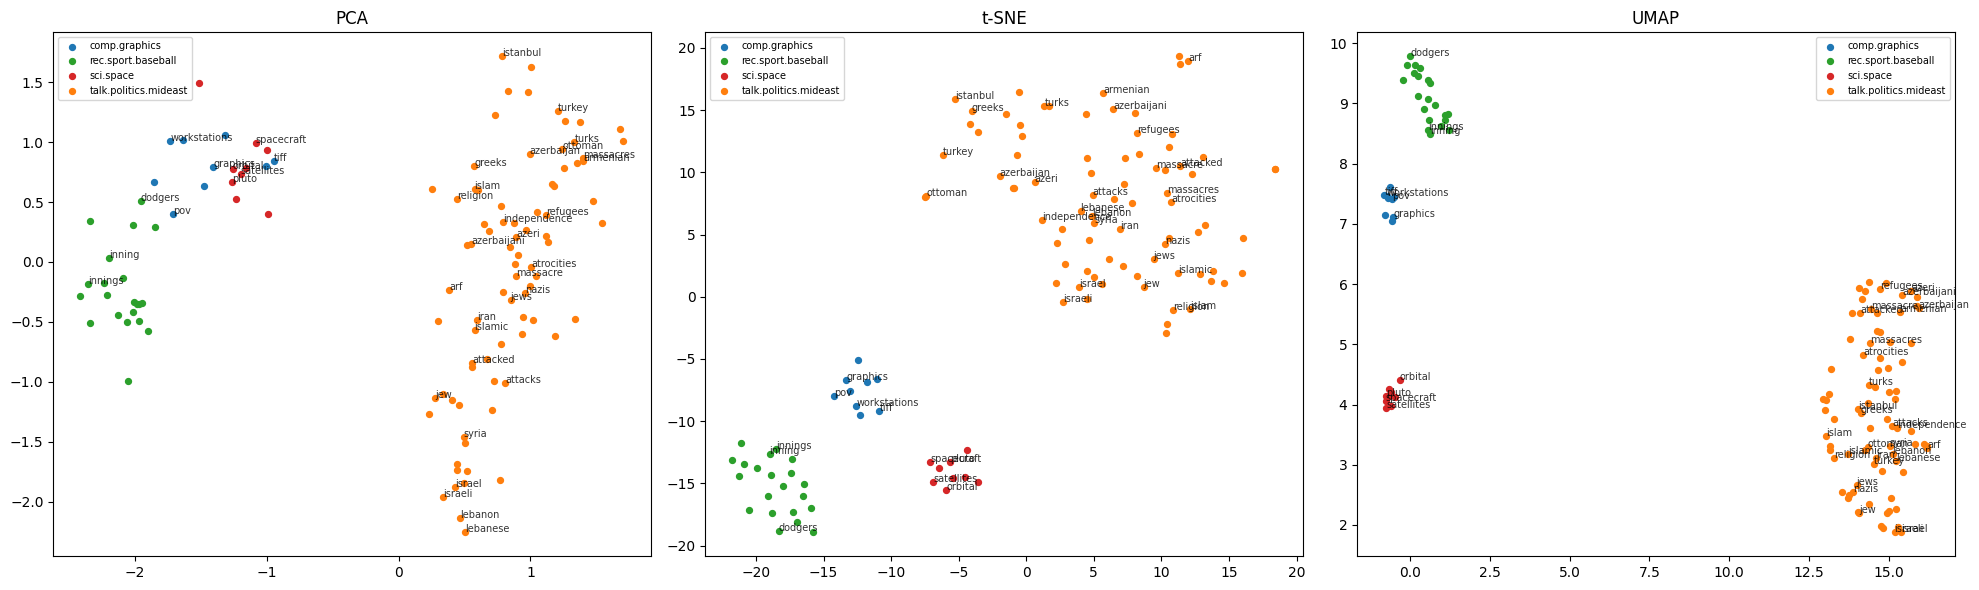

In [ ]:
# Assign each word to the class where it is most over-represented
from collections import defaultdict
cls_count = defaultdict(lambda: np.zeros(len(cats)))
for t, l in zip(tokenized, labels):
    for w in set(t): cls_count[w][l] += 1

candidates = [w for w in w2v_sg.wv.index_to_key[:1500] if cls_count[w].sum() >= 30]
def dominance(w):
    c = cls_count[w] / cls_count[w].sum(); return c.max()
plot_words = sorted(candidates, key=dominance, reverse=True)[:120]
plot_cls = [int(np.argmax(cls_count[w])) for w in plot_words]
M = np.array([w2v_sg.wv[w] for w in plot_words])
colors = ["tab:blue", "tab:green", "tab:red", "tab:orange"]

def scatter(P, title, ax):
    for c in range(len(cats)):
        idx = [i for i, k in enumerate(plot_cls) if k == c]
        ax.scatter(P[idx, 0], P[idx, 1], c=colors[c], label=data.target_names[c], s=18)
    for i, w in enumerate(plot_words[::3]):
        ax.annotate(w, P[i*3], fontsize=7, alpha=0.8)
    ax.set_title(title); ax.legend(fontsize=7)

import umap
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
scatter(PCA(n_components=2, random_state=42).fit_transform(M), "PCA", axes[0])
scatter(TSNE(n_components=2, perplexity=15, random_state=42, init="pca").fit_transform(M), "t-SNE", axes[1])
scatter(umap.UMAP(n_neighbors=10, random_state=42).fit_transform(M), "UMAP", axes[2])
plt.tight_layout(); plt.savefig("embedding_plots.png", dpi=150); plt.show()

In [ ]:
# Export for TensorFlow Embedding Projector (https://projector.tensorflow.org -> Load)
top_words = w2v_sg.wv.index_to_key[:2000]
np.savetxt("vectors.tsv", np.array([w2v_sg.wv[w] for w in top_words]), delimiter="\t")
with open("metadata.tsv", "w") as f:
    for w in top_words: f.write(w + "\n")
print("Saved vectors.tsv and metadata.tsv")
try:
    from google.colab import files
    files.download("vectors.tsv"); files.download("metadata.tsv"); files.download("embedding_plots.png")
except ImportError:
    print("(Not in Colab: files are in the working directory.)")

Saved vectors.tsv and metadata.tsv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Using the Projector:** open https://projector.tensorflow.org -> *Load* -> upload `vectors.tsv` as vectors and `metadata.tsv` as metadata -> choose PCA / t-SNE / UMAP, click a word (e.g. `nasa`) and note its nearest neighbours. Take screenshots for the report.

## 8. Comparison summary

In [ ]:
summary = pd.DataFrame({
  "Technique": ["One-Hot", "BoW / TF-IDF", "Co-occurrence + SVD (LSA)", "Word2Vec (SG/CBOW)", "GloVe", "FastText",
                "Keras Embedding", "BERT", "SBERT"],
  "Type": ["Sparse, discrete", "Sparse, frequency", "Dense, count-based", "Dense, predictive (static)",
           "Dense, global co-occurrence (static)", "Dense, subword (static)", "Dense, task-trained (static)",
           "Dense, contextual", "Dense, contextual sentence"],
  "Captures semantics": ["No", "Weak (topic-level)", "Yes (moderate)", "Yes", "Yes", "Yes", "Task-specific", "Yes (best)", "Yes (sentence)"],
  "Handles OOV": ["No", "No", "No", "No", "No", "Yes (n-grams)", "No (UNK)", "Yes (WordPiece)", "Yes (WordPiece)"],
  "Context-aware": ["No"]*7 + ["Yes", "Yes"],
  "Compute cost": ["Very low", "Low", "Medium (SVD)", "Low-Medium", "Medium (pretrained: none)", "Medium", "Low", "High (GPU helpful)", "Medium-High"],
})
summary

,Technique,Type,Captures semantics,Handles OOV,Context-aware,Compute cost
0,One-Hot,"Sparse, discrete",No,No,No,Very low
1,BoW / TF-IDF,"Sparse, frequency",Weak (topic-level),No,No,Low
2,Co-occurrence + SVD (LSA),"Dense, count-based",Yes (moderate),No,No,Medium (SVD)
3,Word2Vec (SG/CBOW),"Dense, predictive (static)",Yes,No,No,Low-Medium
4,GloVe,"Dense, global co-occurrence (static)",Yes,No,No,Medium (pretrained: none)
5,FastText,"Dense, subword (static)",Yes,Yes (n-grams),No,Medium
6,Keras Embedding,"Dense, task-trained (static)",Task-specific,No (UNK),No,Low
7,BERT,"Dense, contextual",Yes (best),Yes (WordPiece),Yes,High (GPU helpful)
8,SBERT,"Dense, contextual sentence",Yes (sentence),Yes (WordPiece),Yes,Medium-High


### Observations to write up
* Which method gave the most sensible top-5 neighbours for `nasa` / `baseball`? Why?
* How did TF-IDF neighbours differ from Word2Vec neighbours (co-occurring in documents vs. sharing context)?
* What did FastText return for the misspelt words that Word2Vec could not handle?
* How much did BERT's vector for `bank` / `play` change with context?
* Which clusters were visible in PCA vs t-SNE vs UMAP?